##Часть 1 — Анализ FastQC

Работаем с данными `Eg_Treg_S71_R1_001.fastq.gz` и `Eg_Treg_S71_R2_001.fastq.gz`

С помощью SLURM-скрипта `run_fastqc.sh ` проведем анализ файлов и выведем результаты через MultiQC

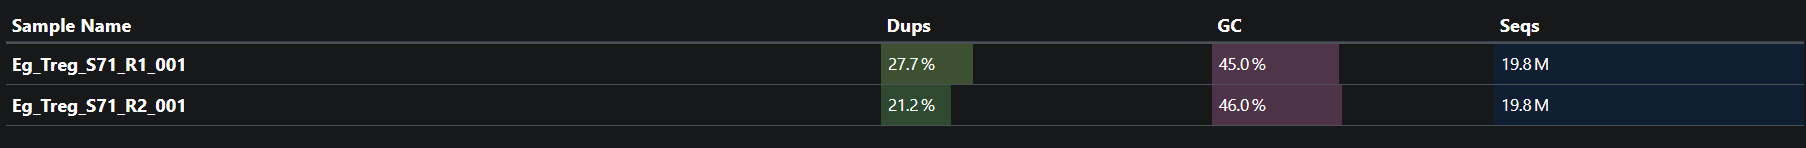

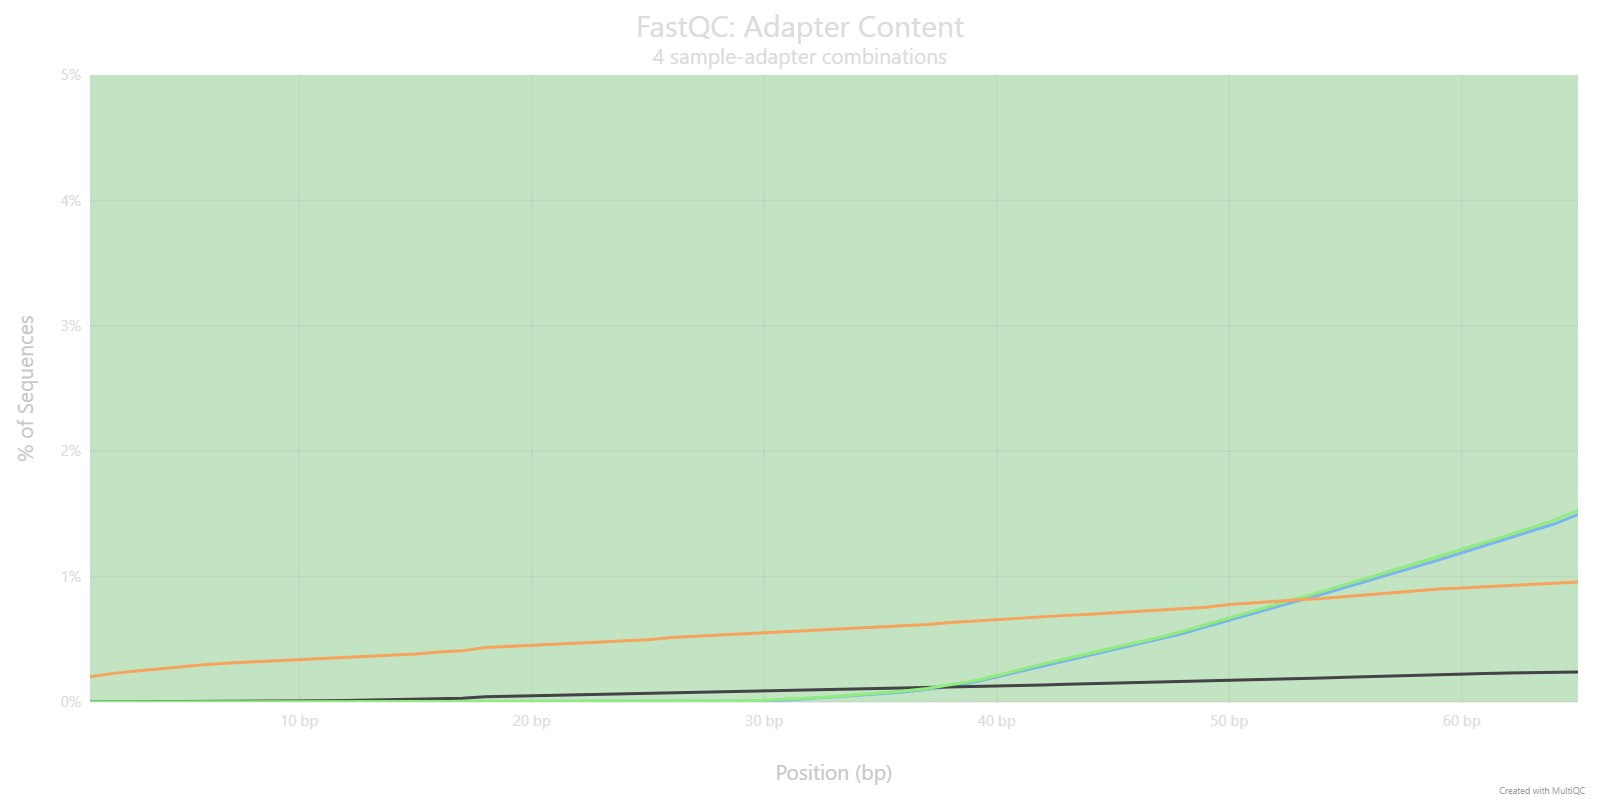

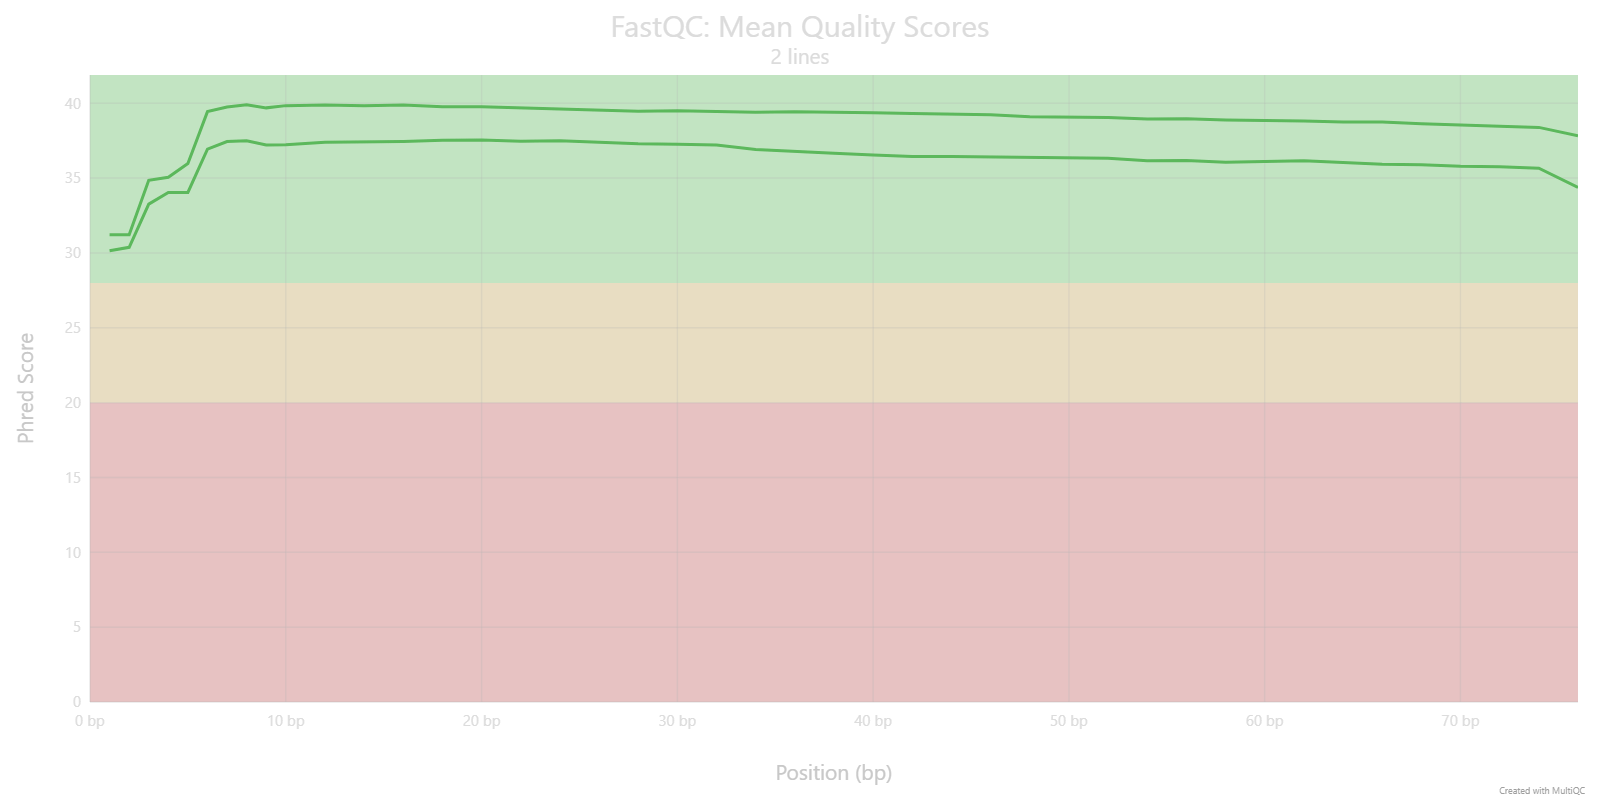

*   На графике видим небольшое присутствие 2 видов адаптеров (4 sample-adapter растут к концу ридов). К позиции 65 bp уровень достигает 1-1.5% последовательностей
*   Оба рида держатся в зелёной зоне (на уровне Q34-Q38) на протяжении всей длины, однако в конце (70-75 bp) качество немного падает

##Часть 2 — Тримминг

Проведем тримминг ридов с помощью скрипта `run_fastp.sh` и повторим анализ качества

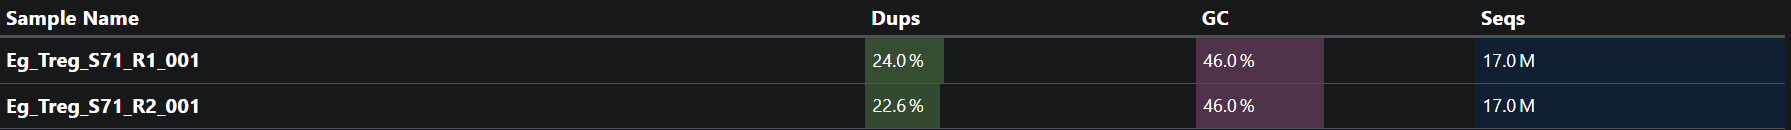

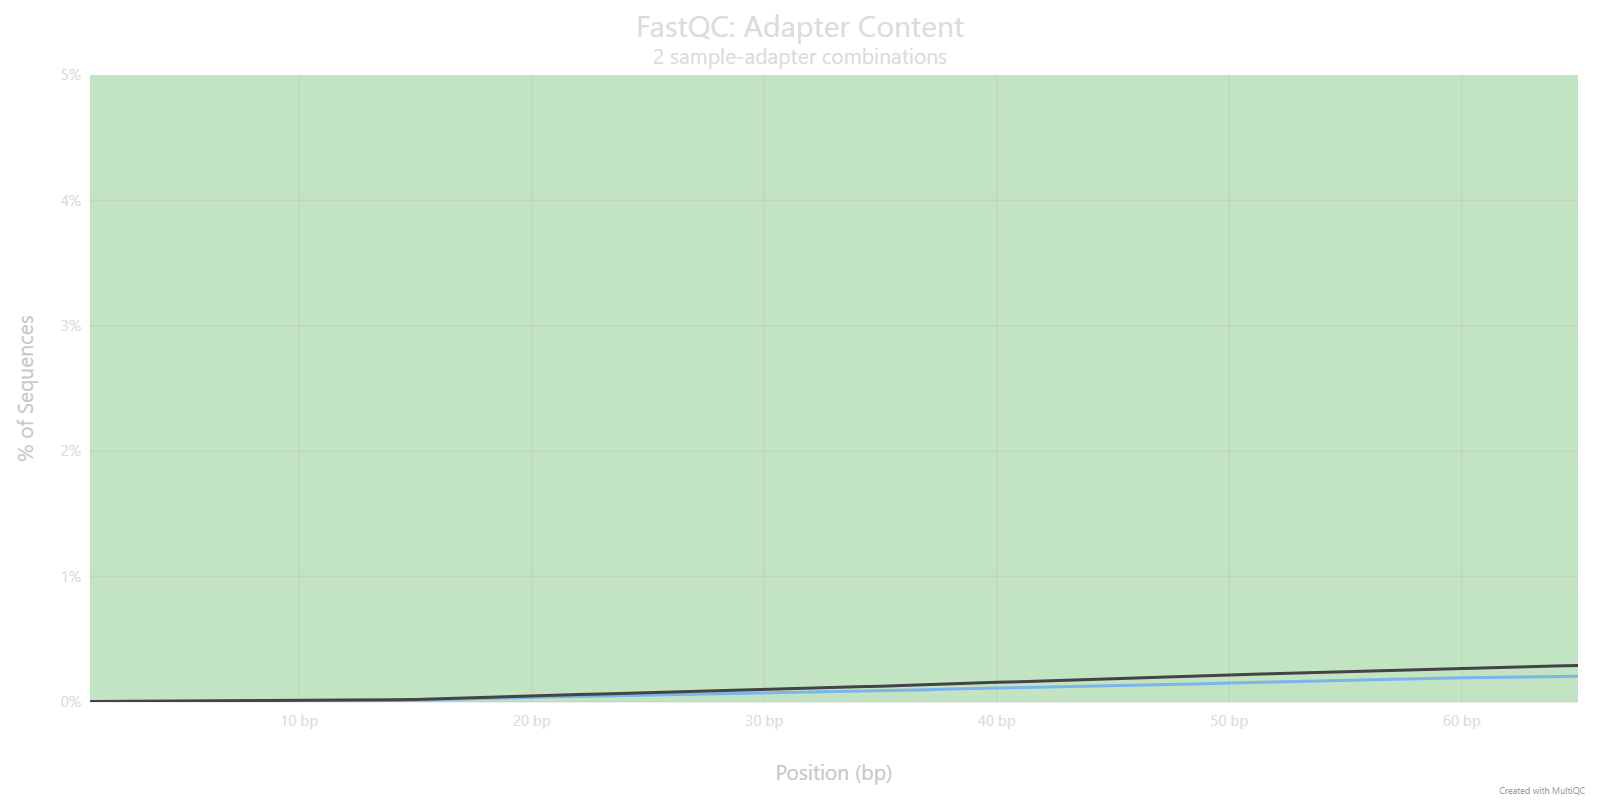

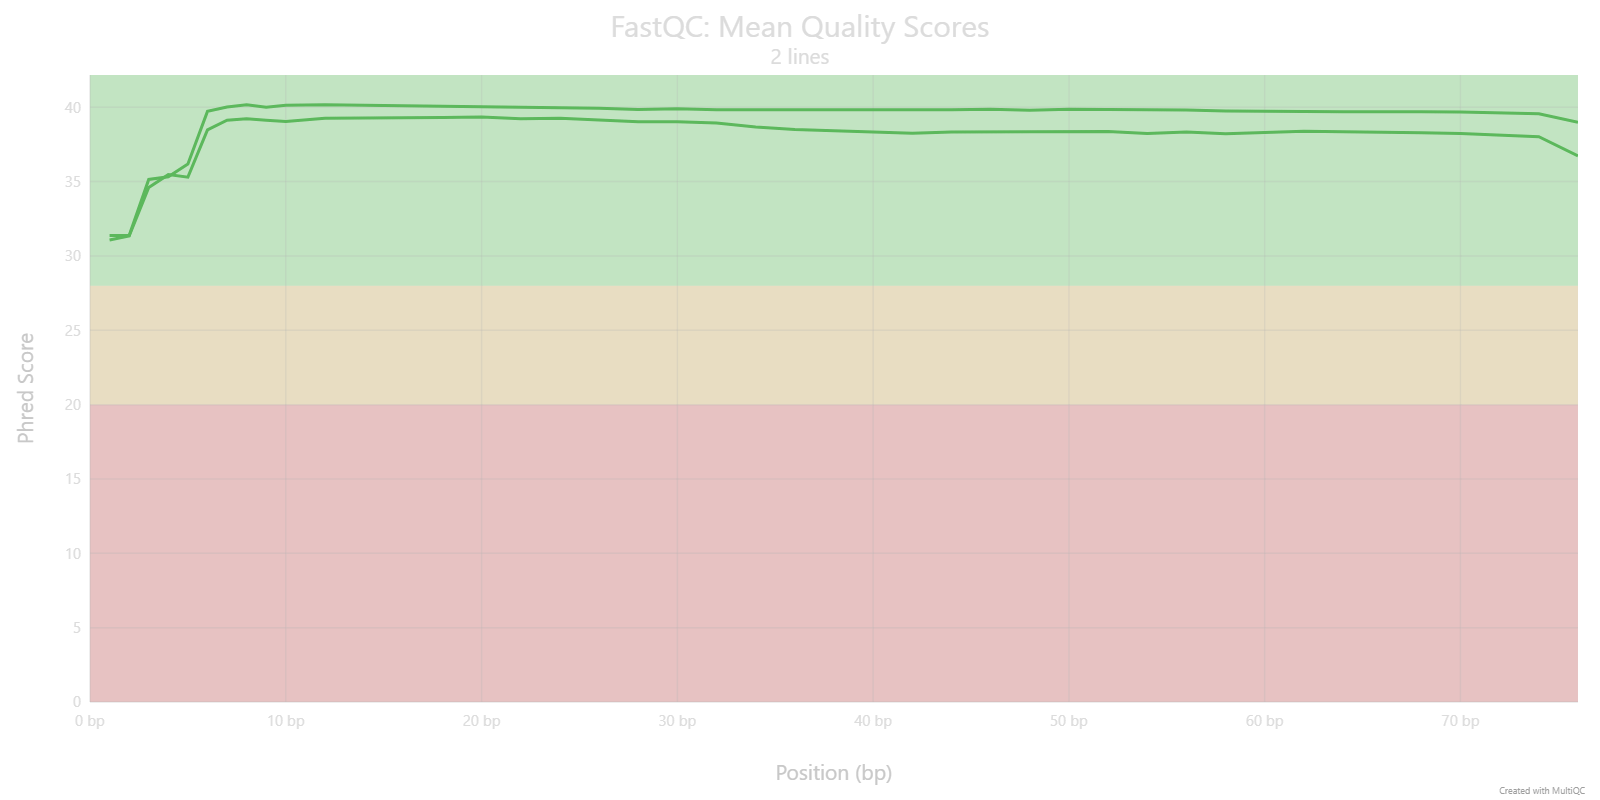

*   После тримминга линии адаптеров практически на нуле (< 0.3%) + количество sample-adapter combinations снизилось с 4 до 2
*   Заметим, что до R1 был лучше по качеству, чем R2. После тримминга качество обоих ридов выровнялось и стало более однородным (линии сблизились)

Для выравнивания будем брать триммированные данные, тк :

1. Отсутствие адаптеров (даже малое количество адаптерных последовательностей может мешать корректному выравниванию, тк они не являются частью генома)

2. Риды выровнялись по качеству (R1 и R2 теперь более сопоставимы, что важно для парного выравнивания)

##Часть 3 — Выравнивание на референсный геном — STAR + StringTie

###1) Загрузка референсного генома

В папку с данными с помощью скрипта `load_ref.sh` загрузим FASTA файл генома человека GRCh38 и GTF файл с аннотацией генов. Далее через `index.sh` построим индекс генома и положим его в папку STAR_index

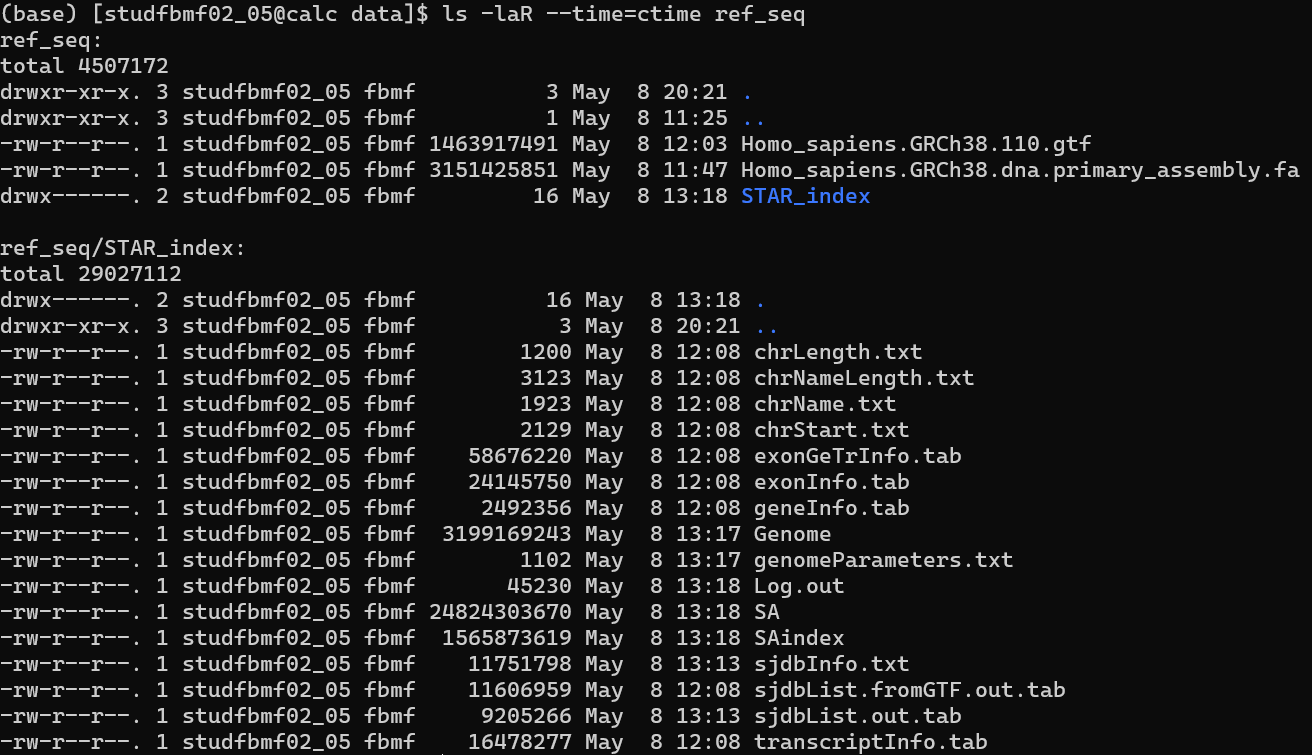

###2) Выравнивание


С помощью STAR будем выравнивать триммированные риды на референсный геном скриптом `run_star.sh`. После для StringTie возьмем выравненные чтения (BAM-файл) + GTF-файл с аннотацией генов и соберем полный транскрипт с подсчетом экспрессии

Получаем новый файл `transcripts.gtf`:

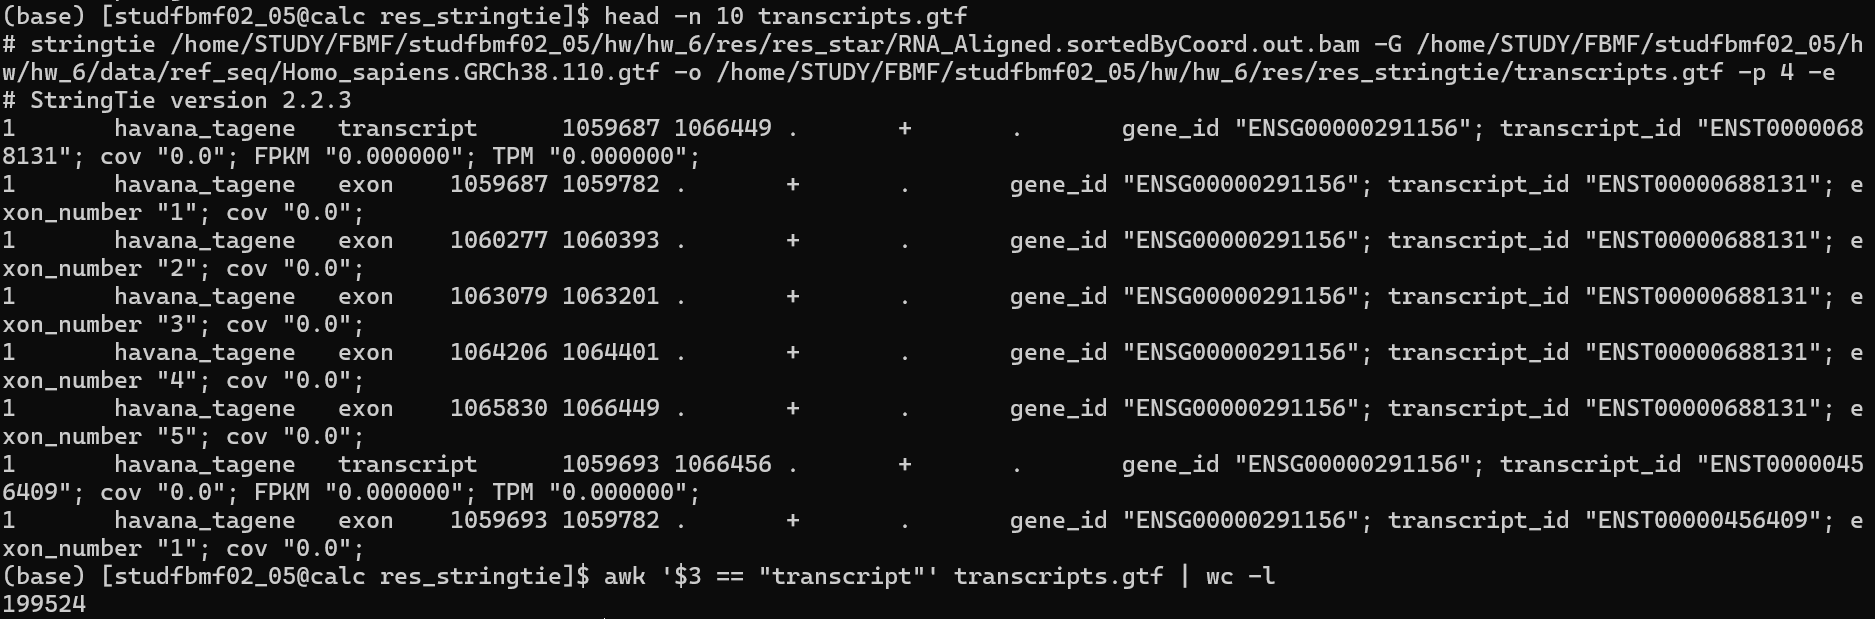

*   Рассмотрим первую строку:

    **1** — номер хромосомы на которой расположен ген

    **havana_tagene** — источник аннотации

    **transcript** — тип элемента который записан в данной строке

    **1059687 — 1066449** - начало и конец элемента

    +/- указание цепи, на которой находится ген

    **id** - идентификаторы гена и транскрипта (для экзонов указывается также порядковый номер)

    **cov "0.0"** - среднее покрытие ридами (0 ⇒ ген не экспрессирован)

    **FPKM "0.0"** - Fragments Per Kilobase per Million (нормализованный уровень экспрессии с учётом длины гена и числа прочитанных ридов)

    **TPM "0.0"** - Transcripts Per Million (уровень экспрессии, нормализованный по длине гена)

*   Bсего транскриптов получилось - 199524

*  Что даёт сборка транскриптов StringTie

StringTie собирает транскриптом на основе выравненных ридов. В результате мы получаем файл `.gtf`, который содержит информацию о структуре и уровне экспрессии всех транскриптов в образце. Это полезно для количественной оценки уровня экспрессии (метрики FPKM и TPM) и для его дальнейшего сравнения между разными условиями или группами образцов + можно изучать альтернативный сплайсинг (изучать какие изоформы одного гена экспрессируются в данном образце)

##Часть 4 — Выравнивание на референсный геном — HTSeq



###1) HTSeq
Теперь также возьмем выравненные риды + аннотацию и с помощью HTSeq (скрипт `run_htseq.sh`) посчитаем сколько фрагментов попало в каждый ген

*   Результаты представлены в `htseq_counts.txt` :

    **Столбец 1** - ID гена

    **Столбец 2** - количество фрагментов



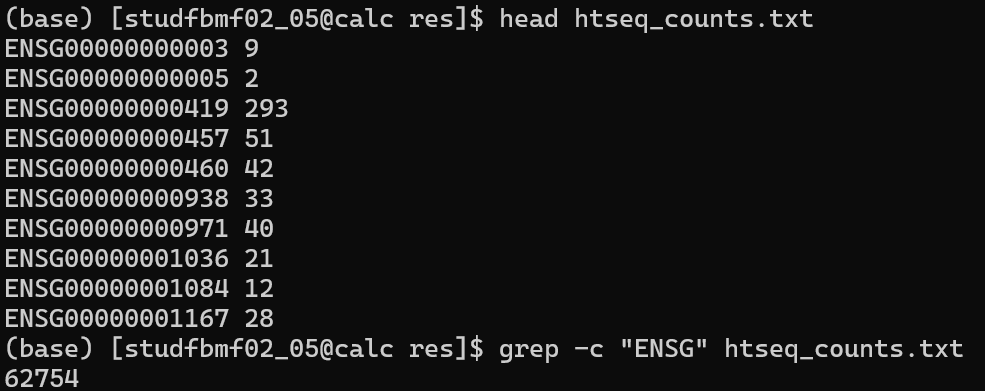

*    Количество уникальных генов - 62754

###2) Сравнение STAR vs HTSeq

Посмотрим на файл каунтов `RNA_ReadsPerGene.out.tab` ,  который STAR генерирует автоматически    
(команда `--quantMode GeneCounts`)

*   Первые 4 строки в начале:

    **N_unmapped** - пары R1+R2 ридов (фрагменты) которые не выровнялись на геном

    **N_multimapping** - пары R1+R2 ридов (фрагменты) выровнявшиеся на несколько мест сразу

    **N_noFeature** - пары R1+R2 ридов (фрагменты) которые попали не в область гена

    **N_ambiguous** - пары R1+R2 ридов (фрагменты) попавшие одновременно в несколько генов

*   Далее идет таблица:

    **Столбец 1** - gene_id

    **Столбец 2** - каунты без учета цепи

    **Столбец 3** - каунты на forward цепи (R1)

    **Столбец 4**- каунты на reverse цепи (R2)

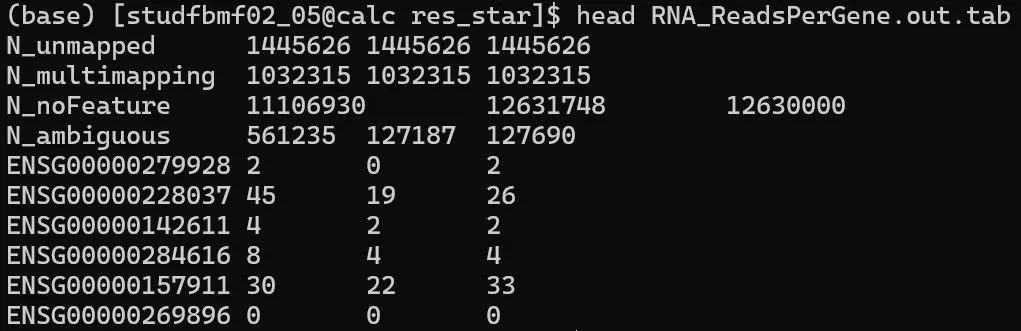

Можно заметить, что сумма каунтов на двух цепях не везде равняется зачению во втором столбце, где цепи не учитываются (например для гена ENSG00000157911). Это объясняется тем, что колонка 2 считает фрагменты (пары R1+R2) как единицу счёта - один фрагмент засчитывается в ген если хотя бы один из его ридов попал в экзон. Колонки 3 и 4 считают отдельные риды независимо друг от друга

>Пример: R1 попадает в межгенную область (+ 1 N_noFeature столбца 3), а R2 того же фрагмента попадает в экзон гена (+1 к гену в колонке 4). При этом также считается +1 к гену столбца 2, поскольку один из ридов пары попал в экзон


Приведем таблицу объединенных результатов для STAR и HTSeq (первый столбец - каунты HTSeq)


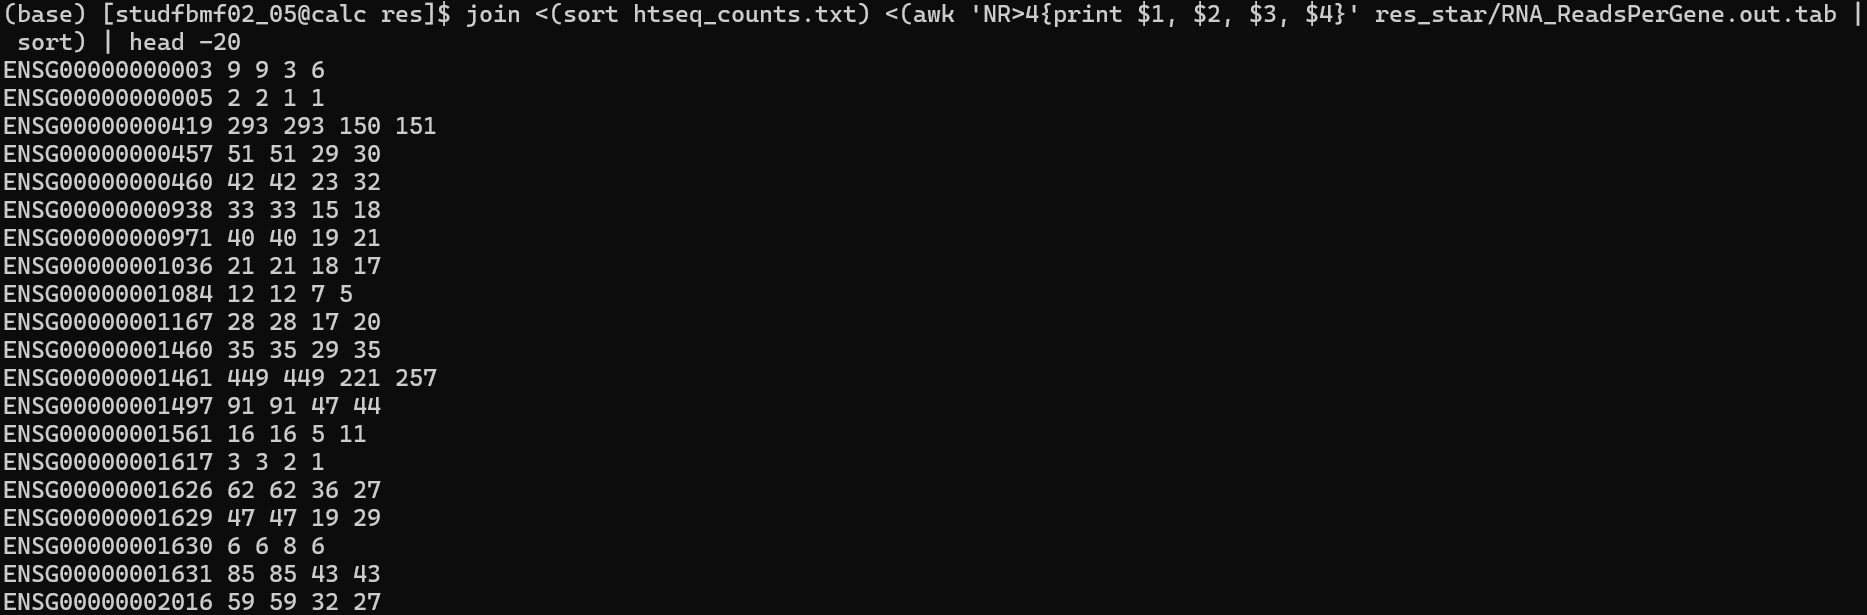

Посмотрим на корреляцию каунтов HTSeq vs STAR в двух случаях: для первого берем 2 колонку STAR, для второго возьмем сумму 3 и 4 столбцов STAR. Для построения используем Python-скрипт `star_vs_htseq_both.py`

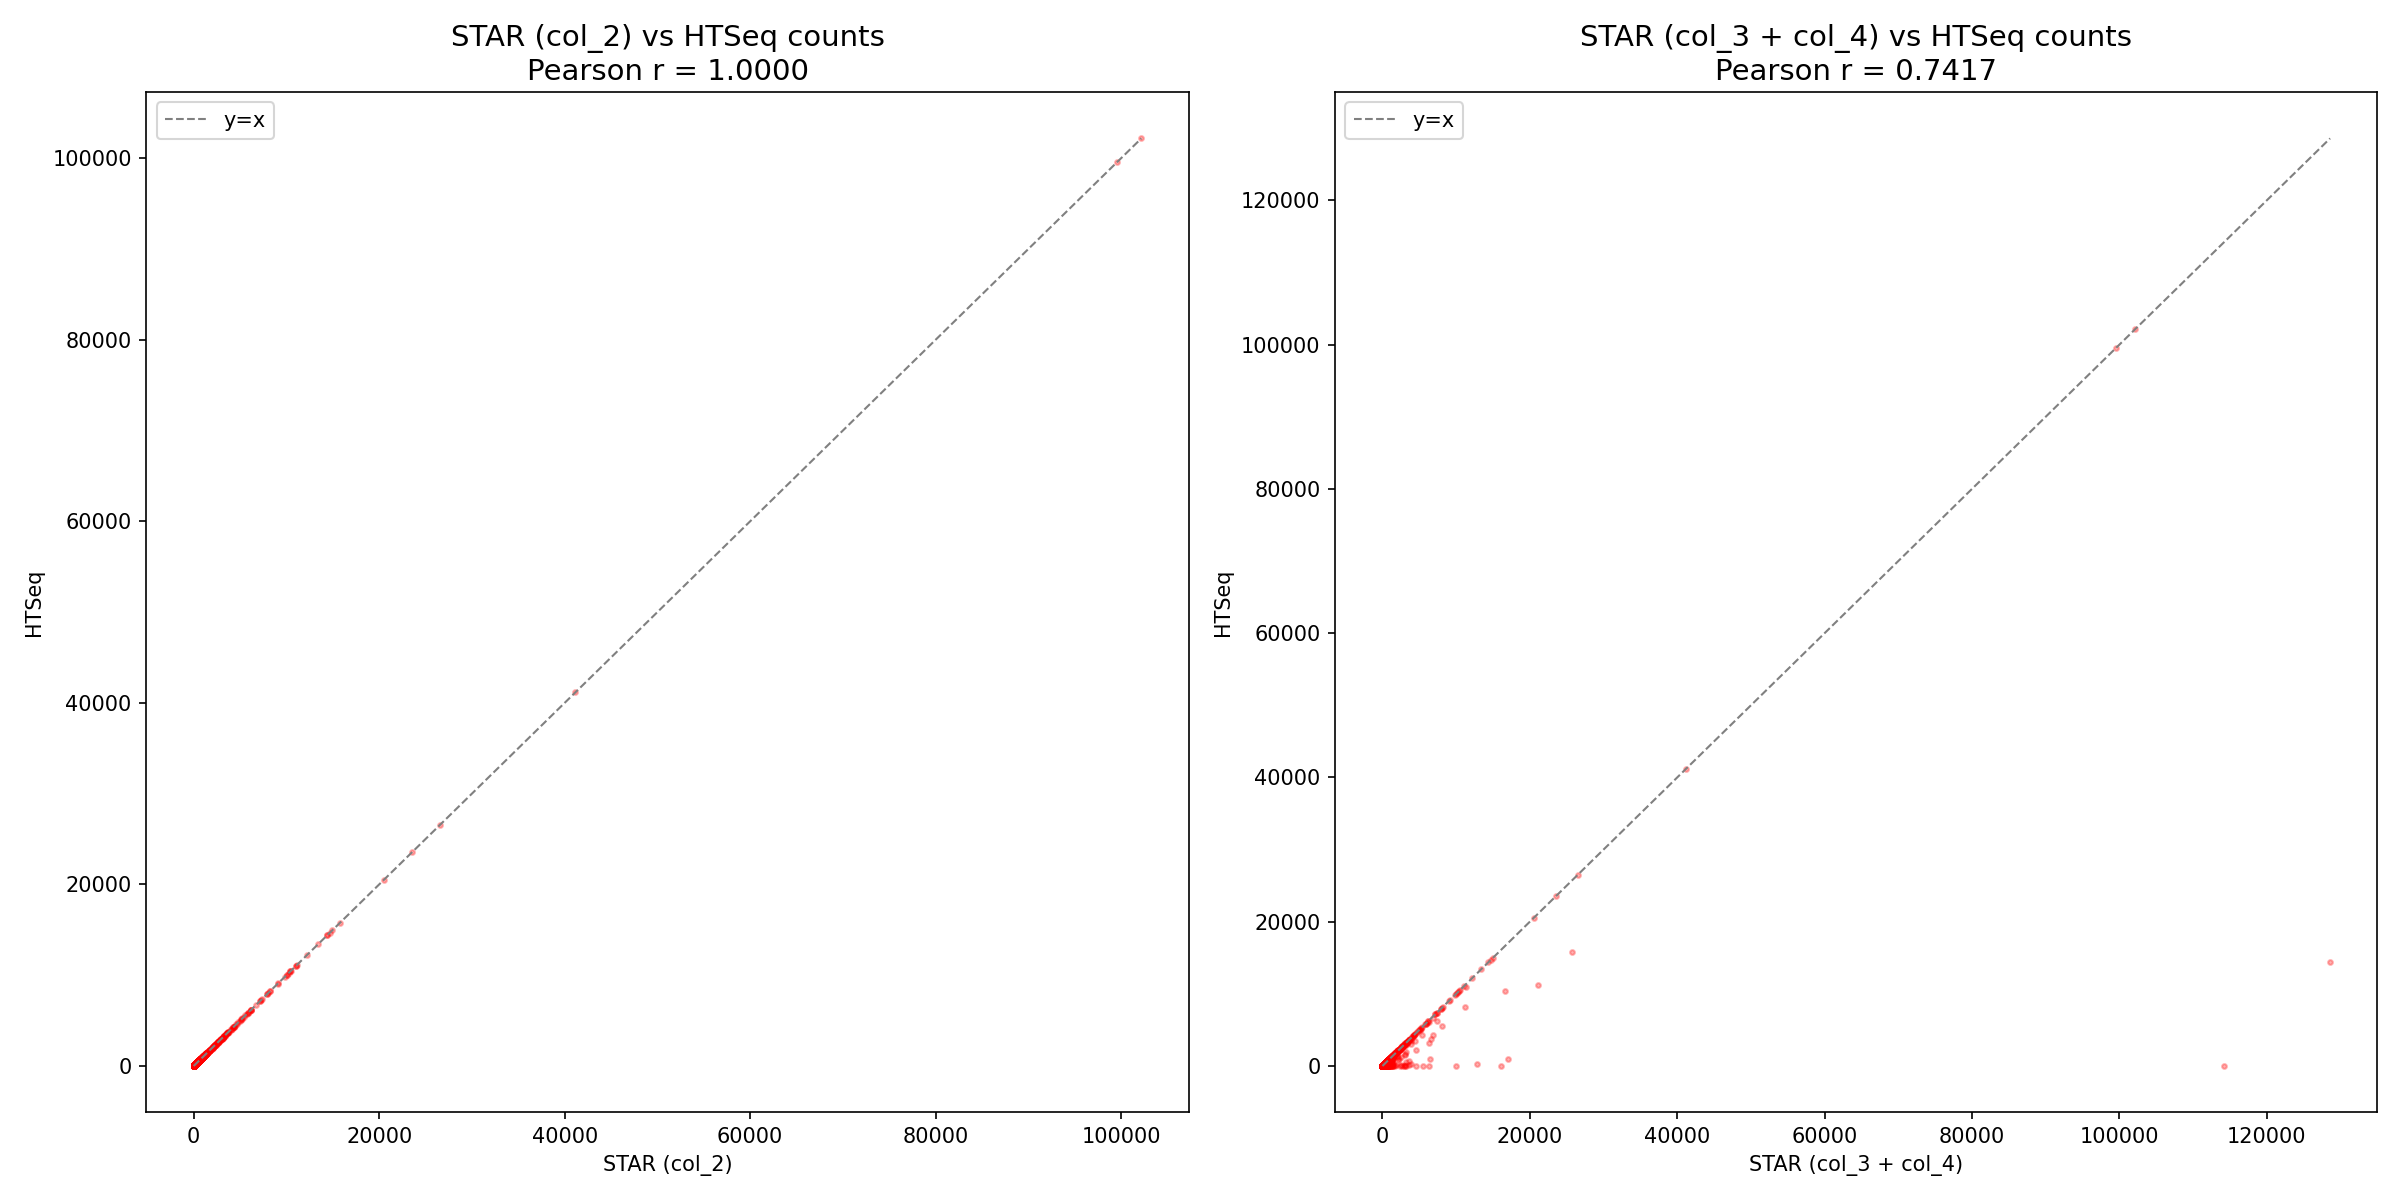

*   На первом графике  мы видим идеальную корреляцию (абсолютнон совпадение каунтов). Это ожидаемый результат, тк оба инструмента использовали одинаковый BAM файл, одинаковый GTF и оба запущены в режиме без учета цепей

*   На втором графике корреляция заметно ниже, многие гены имеют завышенные значения по оси X - это наглядно демонстрирует проблему двойного счёта (суммирование колонок 3 и 4 приводит к тому что каждый фрагмент считается дважды (отдельно R1 и R2), что даёт некорректно завышенные каунты по сравнению с HTSeq)

*   Что лучше использовать для дальнейшего DE‑анализа?

    Оба инструмента дают идентичные результаты (Pearson r = 1.0), поэтому с точки зрения качества данных разницы нет. С практической точки зрения удобнее брать STAR, тк подсчет идет вместе с выравниванием и дополнительного шага делать не надо. HTSeq располагает широким пулом настроек подсчета, поэтому его лучше использовать для каких-то нестандартных выравниваний     

###3) Скриншот папки с результатами

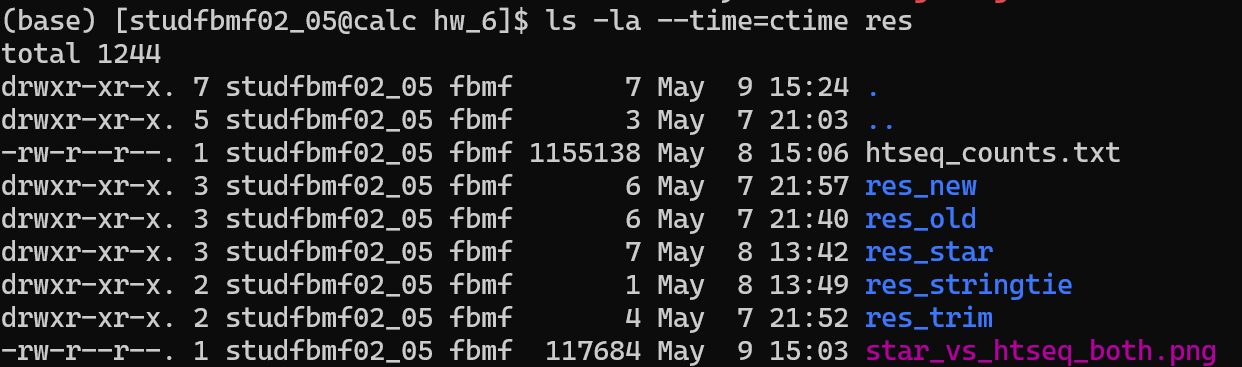

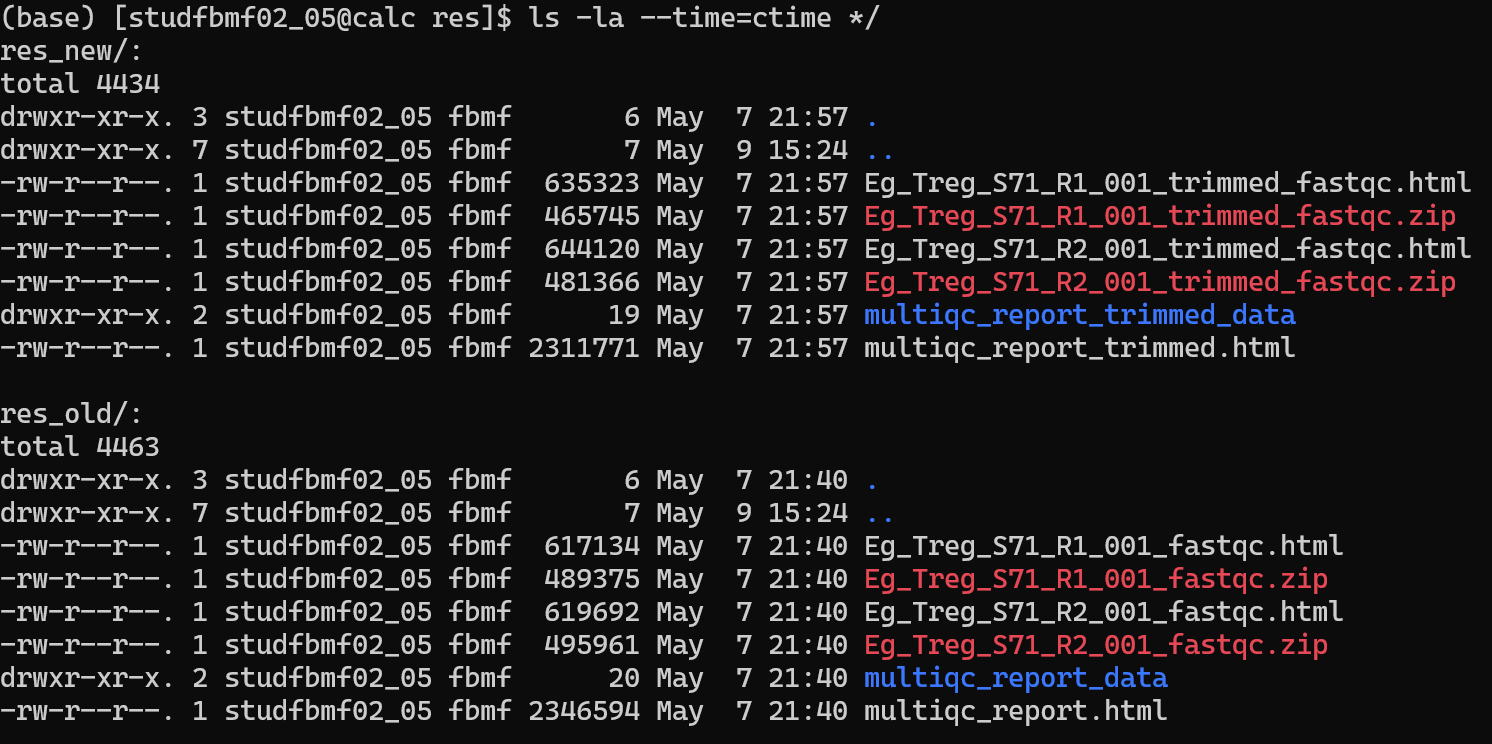

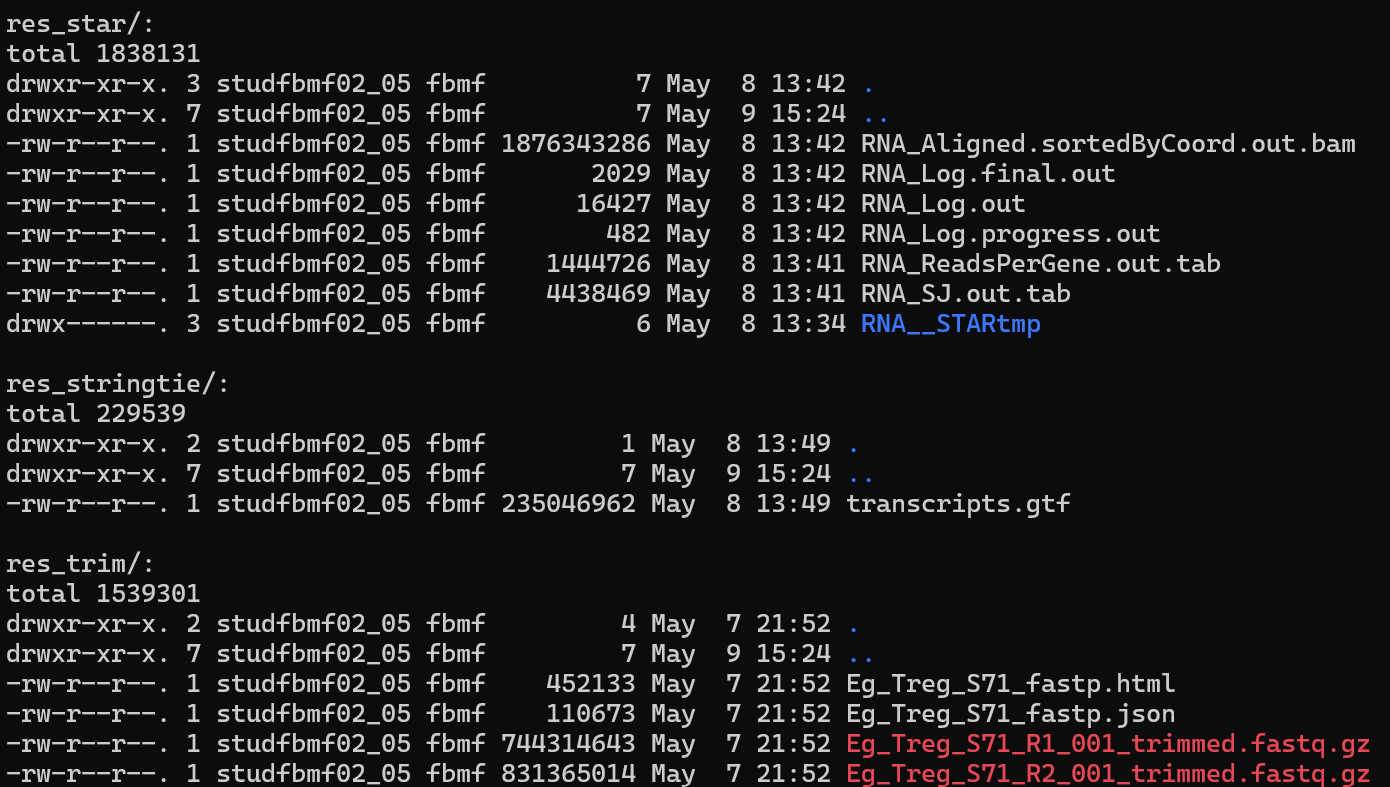